In [3]:
# Setup
import os, re, json, gzip, random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42
SAMPLE_PER_CATEGORY = 2000

random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = "/content/NLP_Assignment3_Transformers_RAG"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

files_map = {
    "sports": "/content/sports.json.gz",
    "cellphones": "/content/cellphones.json.gz",
    "home": "/content/home.json.gz"
}

# Clean
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s.,!?']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Sentiment
def rating_to_sentiment(rating):
    if rating in [1, 2]:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

# Loader
def load_json_gz(path, category, sample_size):
    rows = []

    if not os.path.exists(path):
        print("Missing file:", path)
        return pd.DataFrame()

    with gzip.open(path, "rt", encoding="utf-8", errors="ignore") as f:
        for line in f:
            try:
                item = json.loads(line)

                review = item.get("reviewText", "")
                rating = item.get("overall", None)

                if review and rating is not None:
                    rows.append({
                        "review_text": review,
                        "overall": int(float(rating)),
                        "category": category
                    })

                if len(rows) >= sample_size * 3:
                    break

            except:
                pass

    df = pd.DataFrame(rows)
    df = df.dropna()
    df = df.drop_duplicates(subset=["review_text"])

    if len(df) > sample_size:
        df = df.sample(sample_size, random_state=SEED)

    return df.reset_index(drop=True)

# Load
all_dfs = []

for category, path in files_map.items():
    print("Loading:", category)
    cat_df = load_json_gz(path, category, SAMPLE_PER_CATEGORY)
    print(category, cat_df.shape)
    all_dfs.append(cat_df)

df = pd.concat(all_dfs, ignore_index=True)
df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Process
df["review_text"] = df["review_text"].apply(clean_text)
df = df[df["review_text"].str.len() > 10].reset_index(drop=True)

sentiment_to_id = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

df["sentiment"] = df["overall"].apply(rating_to_sentiment)
df["sentiment_label"] = df["sentiment"].map(sentiment_to_id)

# Length
df["token_count"] = df["review_text"].apply(lambda x: len(x.split()))

q1 = df["token_count"].quantile(0.33)
q2 = df["token_count"].quantile(0.66)

def length_class(count):
    if count <= q1:
        return "short"
    elif count <= q2:
        return "medium"
    else:
        return "long"

length_to_id = {
    "short": 0,
    "medium": 1,
    "long": 2
}

df["review_length_class"] = df["token_count"].apply(length_class)
df["length_label"] = df["review_length_class"].map(length_to_id)

# Columns
final_df = df[
    [
        "review_text",
        "overall",
        "sentiment",
        "sentiment_label",
        "review_length_class",
        "length_label",
        "token_count",
        "category"
    ]
].copy()

# Split
train_df, temp_df = train_test_split(
    final_df,
    test_size=0.30,
    random_state=SEED,
    stratify=final_df["sentiment_label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["sentiment_label"]
)

# Save
processed_path = os.path.join(DATA_DIR, "processed_reviews.csv")
train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

final_df.to_csv(processed_path, index=False)
train_df.to_csv(train_path, index=False)
val_df.to_csv(val_path, index=False)
test_df.to_csv(test_path, index=False)

# Summary
summary = {
    "phase": "Phase 1",
    "sample_per_category": SAMPLE_PER_CATEGORY,
    "total_samples": int(len(final_df)),
    "categories": list(files_map.keys()),
    "train_samples": int(len(train_df)),
    "val_samples": int(len(val_df)),
    "test_samples": int(len(test_df)),
    "sentiment_mapping": {
        "1-2": "negative",
        "3": "neutral",
        "4-5": "positive"
    },
    "derived_feature": "review_length_class",
    "length_classes": length_to_id,
    "short_max_tokens": float(q1),
    "medium_max_tokens": float(q2)
}

summary_path = os.path.join(RESULTS_DIR, "phase1_summary.json")

with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

# Output
print("\nPHASE 1 COMPLETE")
print("Total:", final_df.shape)
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nCategory:")
print(final_df["category"].value_counts())

print("\nSentiment:")
print(final_df["sentiment"].value_counts())

print("\nLength:")
print(final_df["review_length_class"].value_counts())

print("\nSaved:")
print(processed_path)
print(train_path)
print(val_path)
print(test_path)
print(summary_path)

Loading: sports
sports (2000, 3)
Loading: cellphones
cellphones (2000, 3)
Loading: home
home (2000, 3)

PHASE 1 COMPLETE
Total: (5998, 8)
Train: (4198, 8)
Val: (900, 8)
Test: (900, 8)

Category:
category
sports        2000
cellphones    1999
home          1999
Name: count, dtype: int64

Sentiment:
sentiment
positive    4986
negative     578
neutral      434
Name: count, dtype: int64

Length:
review_length_class
long      2039
short     2032
medium    1927
Name: count, dtype: int64

Saved:
/content/NLP_Assignment3_Transformers_RAG/data/processed_reviews.csv
/content/NLP_Assignment3_Transformers_RAG/data/train.csv
/content/NLP_Assignment3_Transformers_RAG/data/val.csv
/content/NLP_Assignment3_Transformers_RAG/data/test.csv
/content/NLP_Assignment3_Transformers_RAG/results/phase1_summary.json


In [4]:
# Download
from google.colab import files

files.download("/content/NLP_Assignment3_Transformers_RAG/data/processed_reviews.csv")
files.download("/content/NLP_Assignment3_Transformers_RAG/data/train.csv")
files.download("/content/NLP_Assignment3_Transformers_RAG/data/val.csv")
files.download("/content/NLP_Assignment3_Transformers_RAG/data/test.csv")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/phase1_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
# Setup
import os, json, re
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from collections import Counter

# Config
SEED = 42
MAX_LEN = 128
MIN_FREQ = 2
MAX_VOCAB_SIZE = 20000
BATCH_SIZE = 32

torch.manual_seed(SEED)

# Paths
BASE_DIR = "/content/NLP_Assignment3_Transformers_RAG"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")
test_path = os.path.join(DATA_DIR, "test.csv")

# Fallback
if not os.path.exists(train_path):
    train_path = "/content/train.csv"
    val_path = "/content/val.csv"
    test_path = "/content/test.csv"

# Load CSV
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

print("Loaded:")
print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

# Tokenizer
def tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r"[a-z0-9']+|[.,!?]", text)
    return tokens

# Word count
counter = Counter()

for text in train_df["review_text"]:
    counter.update(tokenize(text))

# Special tokens
vocab = {
    "<PAD>": 0,
    "<UNK>": 1,
    "<BOS>": 2,
    "<EOS>": 3
}

# Build vocab
for word, freq in counter.most_common():
    if freq < MIN_FREQ:
        continue

    if len(vocab) >= MAX_VOCAB_SIZE:
        break

    if word not in vocab:
        vocab[word] = len(vocab)

# ID maps
id_to_word = {idx: word for word, idx in vocab.items()}

pad_id = vocab["<PAD>"]
unk_id = vocab["<UNK>"]
bos_id = vocab["<BOS>"]
eos_id = vocab["<EOS>"]

print("Vocab size:", len(vocab))

# Encode text
def encode_text(text, max_len=MAX_LEN):
    tokens = tokenize(text)

    ids = [bos_id]

    for token in tokens:
        ids.append(vocab.get(token, unk_id))

    ids.append(eos_id)

    # Truncate
    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = eos_id

    # Mask
    attention_mask = [1] * len(ids)

    # Padding
    while len(ids) < max_len:
        ids.append(pad_id)
        attention_mask.append(0)

    return ids, attention_mask

# Dataset class
class ReviewDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["review_text"].tolist()
        self.sentiment_labels = dataframe["sentiment_label"].tolist()
        self.length_labels = dataframe["length_label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, attention_mask = encode_text(self.texts[idx])

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_labels[idx], dtype=torch.long),
            "length_label": torch.tensor(self.length_labels[idx], dtype=torch.long)
        }

# Datasets
train_dataset = ReviewDataset(train_df)
val_dataset = ReviewDataset(val_df)
test_dataset = ReviewDataset(test_df)

# Dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Batch test
batch = next(iter(train_loader))

print("\nBatch check:")
print("input_ids:", batch["input_ids"].shape)
print("attention_mask:", batch["attention_mask"].shape)
print("sentiment_label:", batch["sentiment_label"].shape)
print("length_label:", batch["length_label"].shape)

# Save folder
os.makedirs(RESULTS_DIR, exist_ok=True)

# Save vocab
vocab_path = os.path.join(RESULTS_DIR, "vocab.json")

with open(vocab_path, "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=4)

# Summary
phase2_summary = {
    "phase": "Phase 2",
    "max_len": MAX_LEN,
    "min_freq": MIN_FREQ,
    "max_vocab_size": MAX_VOCAB_SIZE,
    "final_vocab_size": len(vocab),
    "batch_size": BATCH_SIZE,
    "train_batches": len(train_loader),
    "val_batches": len(val_loader),
    "test_batches": len(test_loader),
    "special_tokens": {
        "PAD": pad_id,
        "UNK": unk_id,
        "BOS": bos_id,
        "EOS": eos_id
    }
}

# Save summary
summary_path = os.path.join(RESULTS_DIR, "phase2_summary.json")

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(phase2_summary, f, indent=4)

# Done
print("\nPHASE 2 COMPLETE")
print("Saved vocab:", vocab_path)
print("Saved summary:", summary_path)

Loaded:
Train: (4198, 8)
Val: (900, 8)
Test: (900, 8)
Vocab size: 8122

Batch check:
input_ids: torch.Size([32, 128])
attention_mask: torch.Size([32, 128])
sentiment_label: torch.Size([32])
length_label: torch.Size([32])

PHASE 2 COMPLETE
Saved vocab: /content/NLP_Assignment3_Transformers_RAG/results/vocab.json
Saved summary: /content/NLP_Assignment3_Transformers_RAG/results/phase2_summary.json


In [6]:
# Download
from google.colab import files

files.download("/content/NLP_Assignment3_Transformers_RAG/results/vocab.json")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/phase2_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [7]:
# Setup
import os, json, math, re
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Config
SEED = 42
MAX_LEN = 128
BATCH_SIZE = 32

D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 256
DROPOUT = 0.1

NUM_SENTIMENT_CLASSES = 3
NUM_LENGTH_CLASSES = 3

torch.manual_seed(SEED)

# Paths
BASE_DIR = "/content/NLP_Assignment3_Transformers_RAG"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

train_path = os.path.join(DATA_DIR, "train.csv")
vocab_path = os.path.join(RESULTS_DIR, "vocab.json")

# Fallback
if not os.path.exists(train_path):
    train_path = "/content/train.csv"

if not os.path.exists(vocab_path):
    vocab_path = "/content/vocab.json"

# Load data
train_df = pd.read_csv(train_path)

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)

VOCAB_SIZE = len(vocab)

pad_id = vocab["<PAD>"]
unk_id = vocab["<UNK>"]
bos_id = vocab["<BOS>"]
eos_id = vocab["<EOS>"]

print("Train:", train_df.shape)
print("Vocab size:", VOCAB_SIZE)

# Tokenizer
def tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r"[a-z0-9']+|[.,!?]", text)
    return tokens

# Encode
def encode_text(text, max_len=MAX_LEN):
    tokens = tokenize(text)

    ids = [bos_id]

    for token in tokens:
        ids.append(vocab.get(token, unk_id))

    ids.append(eos_id)

    # Truncate
    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = eos_id

    # Mask
    attention_mask = [1] * len(ids)

    # Padding
    while len(ids) < max_len:
        ids.append(pad_id)
        attention_mask.append(0)

    return ids, attention_mask

# Dataset
class ReviewDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["review_text"].tolist()
        self.sentiment_labels = dataframe["sentiment_label"].tolist()
        self.length_labels = dataframe["length_label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, attention_mask = encode_text(self.texts[idx])

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_labels[idx], dtype=torch.long),
            "length_label": torch.tensor(self.length_labels[idx], dtype=torch.long)
        }

# DataLoader
train_dataset = ReviewDataset(train_df)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Positional
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# Attention
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)

        output = torch.matmul(attention_weights, v)

        return output, attention_weights

# Multi-head
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention()

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        batch_size = x.size(0)

        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)

        return x

    def combine_heads(self, x):
        batch_size = x.size(0)

        x = x.transpose(1, 2).contiguous()
        x = x.view(batch_size, -1, self.d_model)

        return x

    def forward(self, x, attention_mask=None):
        q = self.q_linear(x)
        k = self.k_linear(x)
        v = self.v_linear(x)

        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        mask = None

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)

        attention_output, attention_weights = self.attention(q, k, v, mask)

        attention_output = self.combine_heads(attention_output)
        attention_output = self.out_linear(attention_output)
        attention_output = self.dropout(attention_output)

        return attention_output, attention_weights

# Feed forward
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

# Encoder block
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()

        self.self_attention = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        attention_output, attention_weights = self.self_attention(x, attention_mask)

        x = self.norm1(x + self.dropout(attention_output))

        ff_output = self.feed_forward(x)

        x = self.norm2(x + self.dropout(ff_output))

        return x, attention_weights

# Encoder model
class ReviewEncoderTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        d_model,
        num_heads,
        num_layers,
        d_ff,
        dropout,
        num_sentiment_classes,
        num_length_classes,
        pad_id
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(
            vocab_size,
            d_model,
            padding_idx=pad_id
        )

        self.position_encoding = PositionalEncoding(d_model, max_len)

        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        self.sentiment_head = nn.Linear(d_model, num_sentiment_classes)
        self.length_head = nn.Linear(d_model, num_length_classes)

    def mean_pooling(self, x, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()

        x = x * mask

        summed = x.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)

        pooled = summed / counts

        return pooled

    def forward(self, input_ids, attention_mask):
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        x = self.dropout(x)

        all_attention_weights = []

        for block in self.encoder_blocks:
            x, attention_weights = block(x, attention_mask)
            all_attention_weights.append(attention_weights)

        review_embedding = self.mean_pooling(x, attention_mask)

        sentiment_logits = self.sentiment_head(review_embedding)
        length_logits = self.length_head(review_embedding)

        return {
            "sentiment_logits": sentiment_logits,
            "length_logits": length_logits,
            "review_embedding": review_embedding,
            "attention_weights": all_attention_weights
        }

# Model
model = ReviewEncoderTransformer(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    num_sentiment_classes=NUM_SENTIMENT_CLASSES,
    num_length_classes=NUM_LENGTH_CLASSES,
    pad_id=pad_id
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)

# Forward test
batch = next(iter(train_loader))

input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)

outputs = model(input_ids, attention_mask)

print("\nForward check:")
print("sentiment_logits:", outputs["sentiment_logits"].shape)
print("length_logits:", outputs["length_logits"].shape)
print("review_embedding:", outputs["review_embedding"].shape)
print("attention_layers:", len(outputs["attention_weights"]))
print("attention_shape:", outputs["attention_weights"][0].shape)

# Save model
model_path = os.path.join(MODELS_DIR, "encoder_initial.pt")

torch.save(model.state_dict(), model_path)

# Summary
phase3_summary = {
    "phase": "Phase 3",
    "model": "Encoder-only Transformer",
    "vocab_size": VOCAB_SIZE,
    "max_len": MAX_LEN,
    "d_model": D_MODEL,
    "num_heads": NUM_HEADS,
    "num_layers": NUM_LAYERS,
    "d_ff": D_FF,
    "dropout": DROPOUT,
    "num_sentiment_classes": NUM_SENTIMENT_CLASSES,
    "num_length_classes": NUM_LENGTH_CLASSES,
    "embedding_dim": D_MODEL,
    "forbidden_modules_used": False,
    "outputs": [
        "sentiment_logits",
        "length_logits",
        "review_embedding"
    ]
}

summary_path = os.path.join(RESULTS_DIR, "phase3_summary.json")

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(phase3_summary, f, indent=4)

# Done
print("\nPHASE 3 COMPLETE")
print("Saved model:", model_path)
print("Saved summary:", summary_path)

Train: (4198, 8)
Vocab size: 8122
Device: cpu

Forward check:
sentiment_logits: torch.Size([32, 3])
length_logits: torch.Size([32, 3])
review_embedding: torch.Size([32, 128])
attention_layers: 2
attention_shape: torch.Size([32, 4, 128, 128])

PHASE 3 COMPLETE
Saved model: /content/NLP_Assignment3_Transformers_RAG/models/encoder_initial.pt
Saved summary: /content/NLP_Assignment3_Transformers_RAG/results/phase3_summary.json


In [8]:
# Download
from google.colab import files

files.download("/content/NLP_Assignment3_Transformers_RAG/models/encoder_initial.pt")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/phase3_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Train: (4198, 8)
Val: (900, 8)
Test: (900, 8)
Vocab: 8122
Device: cpu

Epoch 1/3
Train Loss: 1.2855
Val Loss: 1.1229
Train Sent Acc: 0.4264
Val Sent Acc: 0.3856
Train Len Acc: 0.8876
Val Len Acc: 0.9644
Saved best model

Epoch 2/3
Train Loss: 1.1032
Val Loss: 1.0615
Train Sent Acc: 0.5631
Val Sent Acc: 0.4344
Train Len Acc: 0.9686
Val Len Acc: 0.97
Saved best model

Epoch 3/3
Train Loss: 1.0261
Val Loss: 1.0767
Train Sent Acc: 0.5989
Val Sent Acc: 0.6911
Train Len Acc: 0.9721
Val Len Acc: 0.97

TEST RESULTS
Test Loss: 1.0756
Sentiment Acc: 0.47
Sentiment F1: 0.2971
Length Acc: 0.9633
Length F1: 0.9624


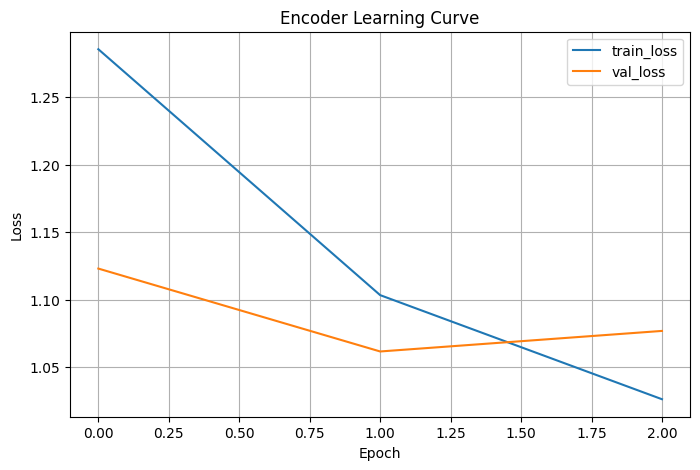


PHASE 4 COMPLETE
Saved model: /content/NLP_Assignment3_Transformers_RAG/models/encoder_trained.pt
Saved metrics: /content/NLP_Assignment3_Transformers_RAG/results/encoder_metrics.json
Saved curves: /content/NLP_Assignment3_Transformers_RAG/results/learning_curves.png
Saved embeddings: /content/NLP_Assignment3_Transformers_RAG/results/train_embeddings.npy
Saved metadata: /content/NLP_Assignment3_Transformers_RAG/results/train_metadata.csv
Embedding shape: (4198, 128)


In [9]:
# Setup
import os, json, math, re, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Config
SEED = 42
MAX_LEN = 128
BATCH_SIZE = 32
EPOCHS = 3
LR = 0.0005

D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 256
DROPOUT = 0.1

NUM_SENTIMENT_CLASSES = 3
NUM_LENGTH_CLASSES = 3

torch.manual_seed(SEED)
np.random.seed(SEED)

# Paths
BASE_DIR = "/content/NLP_Assignment3_Transformers_RAG"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

train_path = os.path.join(DATA_DIR, "train.csv")
val_path = os.path.join(DATA_DIR, "val.csv")
test_path = os.path.join(DATA_DIR, "test.csv")
vocab_path = os.path.join(RESULTS_DIR, "vocab.json")

# Fallback
if not os.path.exists(train_path):
    train_path = "/content/train.csv"
    val_path = "/content/val.csv"
    test_path = "/content/test.csv"

if not os.path.exists(vocab_path):
    vocab_path = "/content/vocab.json"

# Load data
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)

VOCAB_SIZE = len(vocab)

pad_id = vocab["<PAD>"]
unk_id = vocab["<UNK>"]
bos_id = vocab["<BOS>"]
eos_id = vocab["<EOS>"]

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)
print("Vocab:", VOCAB_SIZE)

# Tokenizer
def tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r"[a-z0-9']+|[.,!?]", text)
    return tokens

# Encode
def encode_text(text, max_len=MAX_LEN):
    tokens = tokenize(text)
    ids = [bos_id]

    for token in tokens:
        ids.append(vocab.get(token, unk_id))

    ids.append(eos_id)

    # Truncate
    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = eos_id

    # Mask
    attention_mask = [1] * len(ids)

    # Padding
    while len(ids) < max_len:
        ids.append(pad_id)
        attention_mask.append(0)

    return ids, attention_mask

# Dataset
class ReviewDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["review_text"].tolist()
        self.sentiment_labels = dataframe["sentiment_label"].tolist()
        self.length_labels = dataframe["length_label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, attention_mask = encode_text(self.texts[idx])

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_labels[idx], dtype=torch.long),
            "length_label": torch.tensor(self.length_labels[idx], dtype=torch.long)
        }

# Datasets
train_dataset = ReviewDataset(train_df)
val_dataset = ReviewDataset(val_df)
test_dataset = ReviewDataset(test_df)

# Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Position
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# Attention
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, v)

        return output, attention_weights

# Multi-head
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention()

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)
        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.transpose(1, 2).contiguous()
        x = x.view(batch_size, -1, self.d_model)
        return x

    def forward(self, x, attention_mask=None):
        q = self.q_linear(x)
        k = self.k_linear(x)
        v = self.v_linear(x)

        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        mask = None

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)

        attention_output, attention_weights = self.attention(q, k, v, mask)

        attention_output = self.combine_heads(attention_output)
        attention_output = self.out_linear(attention_output)
        attention_output = self.dropout(attention_output)

        return attention_output, attention_weights

# Feed forward
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

# Encoder block
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()

        self.self_attention = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        attention_output, attention_weights = self.self_attention(x, attention_mask)
        x = self.norm1(x + self.dropout(attention_output))

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x, attention_weights

# Encoder
class ReviewEncoderTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        d_model,
        num_heads,
        num_layers,
        d_ff,
        dropout,
        num_sentiment_classes,
        num_length_classes,
        pad_id
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_encoding = PositionalEncoding(d_model, max_len)

        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        self.sentiment_head = nn.Linear(d_model, num_sentiment_classes)
        self.length_head = nn.Linear(d_model, num_length_classes)

    def mean_pooling(self, x, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x = x * mask

        summed = x.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)

        pooled = summed / counts
        return pooled

    def forward(self, input_ids, attention_mask):
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        x = self.dropout(x)

        all_attention_weights = []

        for block in self.encoder_blocks:
            x, attention_weights = block(x, attention_mask)
            all_attention_weights.append(attention_weights)

        review_embedding = self.mean_pooling(x, attention_mask)

        sentiment_logits = self.sentiment_head(review_embedding)
        length_logits = self.length_head(review_embedding)

        return {
            "sentiment_logits": sentiment_logits,
            "length_logits": length_logits,
            "review_embedding": review_embedding,
            "attention_weights": all_attention_weights
        }

# Model
model = ReviewEncoderTransformer(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    num_sentiment_classes=NUM_SENTIMENT_CLASSES,
    num_length_classes=NUM_LENGTH_CLASSES,
    pad_id=pad_id
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Device:", device)

# Class weights
sentiment_counts = train_df["sentiment_label"].value_counts().sort_index().values
length_counts = train_df["length_label"].value_counts().sort_index().values

sentiment_weights = len(train_df) / (NUM_SENTIMENT_CLASSES * sentiment_counts)
length_weights = len(train_df) / (NUM_LENGTH_CLASSES * length_counts)

sentiment_weights = torch.tensor(sentiment_weights, dtype=torch.float).to(device)
length_weights = torch.tensor(length_weights, dtype=torch.float).to(device)

# Loss
sentiment_criterion = nn.CrossEntropyLoss(weight=sentiment_weights)
length_criterion = nn.CrossEntropyLoss(weight=length_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# Train epoch
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    sentiment_preds = []
    sentiment_true = []
    length_preds = []
    length_true = []

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        sentiment_label = batch["sentiment_label"].to(device)
        length_label = batch["length_label"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)

        sentiment_loss = sentiment_criterion(outputs["sentiment_logits"], sentiment_label)
        length_loss = length_criterion(outputs["length_logits"], length_label)

        loss = sentiment_loss + 0.5 * length_loss

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        sentiment_preds.extend(torch.argmax(outputs["sentiment_logits"], dim=1).detach().cpu().numpy())
        sentiment_true.extend(sentiment_label.detach().cpu().numpy())

        length_preds.extend(torch.argmax(outputs["length_logits"], dim=1).detach().cpu().numpy())
        length_true.extend(length_label.detach().cpu().numpy())

    avg_loss = total_loss / len(loader)

    sentiment_acc = accuracy_score(sentiment_true, sentiment_preds)
    length_acc = accuracy_score(length_true, length_preds)

    return avg_loss, sentiment_acc, length_acc

# Eval epoch
def evaluate(model, loader):
    model.eval()

    total_loss = 0
    sentiment_preds = []
    sentiment_true = []
    length_preds = []
    length_true = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            sentiment_label = batch["sentiment_label"].to(device)
            length_label = batch["length_label"].to(device)

            outputs = model(input_ids, attention_mask)

            sentiment_loss = sentiment_criterion(outputs["sentiment_logits"], sentiment_label)
            length_loss = length_criterion(outputs["length_logits"], length_label)

            loss = sentiment_loss + 0.5 * length_loss

            total_loss += loss.item()

            sentiment_preds.extend(torch.argmax(outputs["sentiment_logits"], dim=1).cpu().numpy())
            sentiment_true.extend(sentiment_label.cpu().numpy())

            length_preds.extend(torch.argmax(outputs["length_logits"], dim=1).cpu().numpy())
            length_true.extend(length_label.cpu().numpy())

    avg_loss = total_loss / len(loader)

    sentiment_acc = accuracy_score(sentiment_true, sentiment_preds)
    length_acc = accuracy_score(length_true, length_preds)

    return avg_loss, sentiment_acc, length_acc, sentiment_true, sentiment_preds, length_true, length_preds

# History
history = {
    "train_loss": [],
    "val_loss": [],
    "train_sentiment_acc": [],
    "val_sentiment_acc": [],
    "train_length_acc": [],
    "val_length_acc": []
}

best_val_loss = float("inf")
best_model_path = os.path.join(MODELS_DIR, "encoder_trained.pt")

# Training
start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss, train_sent_acc, train_len_acc = train_one_epoch(model, train_loader)

    val_loss, val_sent_acc, val_len_acc, _, _, _, _ = evaluate(model, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_sentiment_acc"].append(train_sent_acc)
    history["val_sentiment_acc"].append(val_sent_acc)
    history["train_length_acc"].append(train_len_acc)
    history["val_length_acc"].append(val_len_acc)

    print("Train Loss:", round(train_loss, 4))
    print("Val Loss:", round(val_loss, 4))
    print("Train Sent Acc:", round(train_sent_acc, 4))
    print("Val Sent Acc:", round(val_sent_acc, 4))
    print("Train Len Acc:", round(train_len_acc, 4))
    print("Val Len Acc:", round(val_len_acc, 4))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        print("Saved best model")

training_time = time.time() - start_time

# Load best
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Test eval
test_loss, test_sent_acc, test_len_acc, sent_true, sent_pred, len_true, len_pred = evaluate(model, test_loader)

sent_precision, sent_recall, sent_f1, _ = precision_recall_fscore_support(
    sent_true,
    sent_pred,
    average="macro",
    zero_division=0
)

len_precision, len_recall, len_f1, _ = precision_recall_fscore_support(
    len_true,
    len_pred,
    average="macro",
    zero_division=0
)

sent_cm = confusion_matrix(sent_true, sent_pred).tolist()
len_cm = confusion_matrix(len_true, len_pred).tolist()

print("\nTEST RESULTS")
print("Test Loss:", round(test_loss, 4))
print("Sentiment Acc:", round(test_sent_acc, 4))
print("Sentiment F1:", round(sent_f1, 4))
print("Length Acc:", round(test_len_acc, 4))
print("Length F1:", round(len_f1, 4))

# Plot
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Encoder Learning Curve")
plt.legend()
plt.grid(True)

curve_path = os.path.join(RESULTS_DIR, "learning_curves.png")
plt.savefig(curve_path, dpi=150, bbox_inches="tight")
plt.show()

# Embeddings
def save_embeddings(model, loader, dataframe):
    model.eval()

    all_embeddings = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids, attention_mask)
            embeddings = outputs["review_embedding"].cpu().numpy()

            all_embeddings.append(embeddings)

    all_embeddings = np.vstack(all_embeddings)

    return all_embeddings

train_no_shuffle_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)

train_embeddings = save_embeddings(model, train_no_shuffle_loader, train_df)

embeddings_path = os.path.join(RESULTS_DIR, "train_embeddings.npy")
metadata_path = os.path.join(RESULTS_DIR, "train_metadata.csv")

np.save(embeddings_path, train_embeddings)

train_df[
    [
        "review_text",
        "overall",
        "sentiment",
        "sentiment_label",
        "review_length_class",
        "length_label",
        "category"
    ]
].to_csv(metadata_path, index=False)

# Metrics
metrics = {
    "phase": "Phase 4",
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "training_time_seconds": round(training_time, 2),
    "best_val_loss": best_val_loss,
    "test_loss": test_loss,
    "sentiment": {
        "accuracy": test_sent_acc,
        "precision_macro": sent_precision,
        "recall_macro": sent_recall,
        "f1_macro": sent_f1,
        "confusion_matrix": sent_cm
    },
    "length_feature": {
        "accuracy": test_len_acc,
        "precision_macro": len_precision,
        "recall_macro": len_recall,
        "f1_macro": len_f1,
        "confusion_matrix": len_cm
    },
    "history": history,
    "embedding_shape": list(train_embeddings.shape),
    "combined_loss": "sentiment_loss + 0.5 * length_loss"
}

metrics_path = os.path.join(RESULTS_DIR, "encoder_metrics.json")

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4)

# Done
print("\nPHASE 4 COMPLETE")
print("Saved model:", best_model_path)
print("Saved metrics:", metrics_path)
print("Saved curves:", curve_path)
print("Saved embeddings:", embeddings_path)
print("Saved metadata:", metadata_path)
print("Embedding shape:", train_embeddings.shape)

In [10]:
# Download
from google.colab import files

files.download("/content/NLP_Assignment3_Transformers_RAG/models/encoder_trained.pt")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/encoder_metrics.json")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/learning_curves.png")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/train_embeddings.npy")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/train_metadata.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
# Setup
import os, json, math, re
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Config
SEED = 42
MAX_LEN = 128
BATCH_SIZE = 32

D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 256
DROPOUT = 0.1

NUM_SENTIMENT_CLASSES = 3
NUM_LENGTH_CLASSES = 3
TOP_K = 3

torch.manual_seed(SEED)
np.random.seed(SEED)

# Paths
BASE_DIR = "/content/NLP_Assignment3_Transformers_RAG"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(BASE_DIR, "models")

test_path = os.path.join(DATA_DIR, "test.csv")
vocab_path = os.path.join(RESULTS_DIR, "vocab.json")
model_path = os.path.join(MODELS_DIR, "encoder_trained.pt")
embeddings_path = os.path.join(RESULTS_DIR, "train_embeddings.npy")
metadata_path = os.path.join(RESULTS_DIR, "train_metadata.csv")

# Fallback
if not os.path.exists(test_path):
    test_path = "/content/test.csv"

if not os.path.exists(vocab_path):
    vocab_path = "/content/vocab.json"

if not os.path.exists(model_path):
    model_path = "/content/encoder_trained.pt"

if not os.path.exists(embeddings_path):
    embeddings_path = "/content/train_embeddings.npy"

if not os.path.exists(metadata_path):
    metadata_path = "/content/train_metadata.csv"

# Load files
test_df = pd.read_csv(test_path)
train_metadata = pd.read_csv(metadata_path)
train_embeddings = np.load(embeddings_path)

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)

VOCAB_SIZE = len(vocab)

pad_id = vocab["<PAD>"]
unk_id = vocab["<UNK>"]
bos_id = vocab["<BOS>"]
eos_id = vocab["<EOS>"]

print("Test:", test_df.shape)
print("Train metadata:", train_metadata.shape)
print("Train embeddings:", train_embeddings.shape)
print("Vocab:", VOCAB_SIZE)

# Tokenizer
def tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r"[a-z0-9']+|[.,!?]", text)
    return tokens

# Encode
def encode_text(text, max_len=MAX_LEN):
    tokens = tokenize(text)

    ids = [bos_id]

    for token in tokens:
        ids.append(vocab.get(token, unk_id))

    ids.append(eos_id)

    # Truncate
    if len(ids) > max_len:
        ids = ids[:max_len]
        ids[-1] = eos_id

    # Mask
    attention_mask = [1] * len(ids)

    # Padding
    while len(ids) < max_len:
        ids.append(pad_id)
        attention_mask.append(0)

    return ids, attention_mask

# Dataset
class ReviewDataset(Dataset):
    def __init__(self, dataframe):
        self.texts = dataframe["review_text"].tolist()
        self.sentiment_labels = dataframe["sentiment_label"].tolist()
        self.length_labels = dataframe["length_label"].tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        input_ids, attention_mask = encode_text(self.texts[idx])

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "sentiment_label": torch.tensor(self.sentiment_labels[idx], dtype=torch.long),
            "length_label": torch.tensor(self.length_labels[idx], dtype=torch.long),
            "index": torch.tensor(idx, dtype=torch.long)
        }

# Loader
test_dataset = ReviewDataset(test_df)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# Position
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# Attention
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, v)

        return output, attention_weights

# Multi-head
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention()

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)
        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.transpose(1, 2).contiguous()
        x = x.view(batch_size, -1, self.d_model)
        return x

    def forward(self, x, attention_mask=None):
        q = self.q_linear(x)
        k = self.k_linear(x)
        v = self.v_linear(x)

        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        mask = None

        if attention_mask is not None:
            mask = attention_mask.unsqueeze(1).unsqueeze(2)

        attention_output, attention_weights = self.attention(q, k, v, mask)

        attention_output = self.combine_heads(attention_output)
        attention_output = self.out_linear(attention_output)
        attention_output = self.dropout(attention_output)

        return attention_output, attention_weights

# Feed forward
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

# Encoder block
class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()

        self.self_attention = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        attention_output, attention_weights = self.self_attention(x, attention_mask)
        x = self.norm1(x + self.dropout(attention_output))

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x, attention_weights

# Encoder
class ReviewEncoderTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        d_model,
        num_heads,
        num_layers,
        d_ff,
        dropout,
        num_sentiment_classes,
        num_length_classes,
        pad_id
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_encoding = PositionalEncoding(d_model, max_len)

        self.encoder_blocks = nn.ModuleList([
            EncoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)

        self.sentiment_head = nn.Linear(d_model, num_sentiment_classes)
        self.length_head = nn.Linear(d_model, num_length_classes)

    def mean_pooling(self, x, attention_mask):
        mask = attention_mask.unsqueeze(-1).float()
        x = x * mask

        summed = x.sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1)

        pooled = summed / counts
        return pooled

    def forward(self, input_ids, attention_mask):
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        x = self.dropout(x)

        all_attention_weights = []

        for block in self.encoder_blocks:
            x, attention_weights = block(x, attention_mask)
            all_attention_weights.append(attention_weights)

        review_embedding = self.mean_pooling(x, attention_mask)

        sentiment_logits = self.sentiment_head(review_embedding)
        length_logits = self.length_head(review_embedding)

        return {
            "sentiment_logits": sentiment_logits,
            "length_logits": length_logits,
            "review_embedding": review_embedding,
            "attention_weights": all_attention_weights
        }

# Model
model = ReviewEncoderTransformer(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    num_sentiment_classes=NUM_SENTIMENT_CLASSES,
    num_length_classes=NUM_LENGTH_CLASSES,
    pad_id=pad_id
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

print("Device:", device)
print("Model loaded")

# Normalize
def normalize_vectors(x):
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    norm = np.clip(norm, 1e-8, None)
    return x / norm

# Query embeddings
def get_test_embeddings(model, loader):
    all_embeddings = []
    all_sent_preds = []
    all_len_preds = []

    model.eval()

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids, attention_mask)

            embeddings = outputs["review_embedding"].cpu().numpy()
            sent_preds = torch.argmax(outputs["sentiment_logits"], dim=1).cpu().numpy()
            len_preds = torch.argmax(outputs["length_logits"], dim=1).cpu().numpy()

            all_embeddings.append(embeddings)
            all_sent_preds.extend(sent_preds)
            all_len_preds.extend(len_preds)

    all_embeddings = np.vstack(all_embeddings)

    return all_embeddings, all_sent_preds, all_len_preds

test_embeddings, sent_preds, len_preds = get_test_embeddings(model, test_loader)

print("Test embeddings:", test_embeddings.shape)

# Similarity
train_embeddings_norm = normalize_vectors(train_embeddings)
test_embeddings_norm = normalize_vectors(test_embeddings)

similarity_matrix = np.matmul(test_embeddings_norm, train_embeddings_norm.T)

print("Similarity matrix:", similarity_matrix.shape)

# Retrieve
id_to_sentiment = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

id_to_length = {
    0: "short",
    1: "medium",
    2: "long"
}

retrieval_examples = []
retrieval_rows = []

num_examples_to_save = min(20, len(test_df))

for query_idx in range(len(test_df)):
    sims = similarity_matrix[query_idx]

    top_indices = np.argsort(sims)[::-1][:TOP_K]
    top_scores = sims[top_indices]

    query_review = test_df.iloc[query_idx]

    row = {
        "query_index": int(query_idx),
        "query_review": query_review["review_text"],
        "query_true_sentiment": query_review["sentiment"],
        "query_true_length": query_review["review_length_class"],
        "predicted_sentiment": id_to_sentiment[int(sent_preds[query_idx])],
        "predicted_length": id_to_length[int(len_preds[query_idx])],
        "top_1_similarity": float(top_scores[0]),
        "top_1_review": train_metadata.iloc[top_indices[0]]["review_text"],
        "top_1_sentiment": train_metadata.iloc[top_indices[0]]["sentiment"],
        "top_1_category": train_metadata.iloc[top_indices[0]]["category"]
    }

    retrieval_rows.append(row)

    if query_idx < num_examples_to_save:
        retrieved = []

        for rank, train_idx in enumerate(top_indices):
            train_review = train_metadata.iloc[train_idx]

            retrieved.append({
                "rank": rank + 1,
                "train_index": int(train_idx),
                "similarity": float(top_scores[rank]),
                "review_text": train_review["review_text"],
                "sentiment": train_review["sentiment"],
                "length_class": train_review["review_length_class"],
                "category": train_review["category"],
                "rating": int(train_review["overall"])
            })

        retrieval_examples.append({
            "query_index": int(query_idx),
            "query_review": query_review["review_text"],
            "true_sentiment": query_review["sentiment"],
            "true_length_class": query_review["review_length_class"],
            "predicted_sentiment": id_to_sentiment[int(sent_preds[query_idx])],
            "predicted_length_class": id_to_length[int(len_preds[query_idx])],
            "retrieved_reviews": retrieved
        })

retrieval_df = pd.DataFrame(retrieval_rows)

# Save
examples_path = os.path.join(RESULTS_DIR, "retrieval_examples.json")
analysis_path = os.path.join(RESULTS_DIR, "retrieval_analysis.csv")

with open(examples_path, "w", encoding="utf-8") as f:
    json.dump(retrieval_examples, f, indent=4)

retrieval_df.to_csv(analysis_path, index=False)

# Metrics
same_sentiment = (
    retrieval_df["query_true_sentiment"] == retrieval_df["top_1_sentiment"]
).mean()

avg_top1_similarity = retrieval_df["top_1_similarity"].mean()

phase5_summary = {
    "phase": "Phase 5",
    "module": "Cosine similarity retrieval",
    "top_k": TOP_K,
    "train_embedding_shape": list(train_embeddings.shape),
    "test_embedding_shape": list(test_embeddings.shape),
    "similarity_metric": "cosine similarity",
    "saved_examples": len(retrieval_examples),
    "total_test_queries": int(len(test_df)),
    "top1_same_sentiment_rate": float(same_sentiment),
    "average_top1_similarity": float(avg_top1_similarity)
}

summary_path = os.path.join(RESULTS_DIR, "phase5_summary.json")

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(phase5_summary, f, indent=4)

# Print samples
print("\nRetrieval sample:")
for i in range(min(3, len(retrieval_examples))):
    ex = retrieval_examples[i]

    print("\nQuery:", ex["query_review"][:250])
    print("True:", ex["true_sentiment"], "| Pred:", ex["predicted_sentiment"])

    for r in ex["retrieved_reviews"]:
        print("Rank", r["rank"], "| Sim:", round(r["similarity"], 4), "| Sent:", r["sentiment"])
        print(r["review_text"][:180])

print("\nPHASE 5 COMPLETE")
print("Top-k:", TOP_K)
print("Top1 same sentiment rate:", round(same_sentiment, 4))
print("Average top1 similarity:", round(avg_top1_similarity, 4))
print("Saved examples:", examples_path)
print("Saved analysis:", analysis_path)
print("Saved summary:", summary_path)

Test: (900, 8)
Train metadata: (4198, 7)
Train embeddings: (4198, 128)
Vocab: 8122
Device: cpu
Model loaded
Test embeddings: (900, 128)
Similarity matrix: (900, 4198)

Retrieval sample:

Query: this works so well...leaves my old all metal one in it's dust! careful...sharp and quick...a bit bulky for hanging against a wall, but easy to find in a drawer...
True: positive | Pred: positive
Rank 1 | Sim: 0.9469 | Sent: positive
work to secure the towers ..these should stop the casual theft but i think they would only be a minor inconvenience to the dedicated thief..easy to install..easy to use.. but as wi
Rank 2 | Sim: 0.9409 | Sent: positive
this is a compass, not much to say about it. its lightweight, works as advertised. i keep it in my backpack when i go hiking. works well, doesn't get stuck, easy to read. no compla
Rank 3 | Sim: 0.9321 | Sent: positive
this was easy to set up and fun for the grandkid. i like the quality of the materials. it seems well made and should stand up to rugged

In [12]:
# Download
from google.colab import files

files.download("/content/NLP_Assignment3_Transformers_RAG/results/retrieval_examples.json")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/retrieval_analysis.csv")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/phase5_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [13]:
# Setup
import os, json, math, re, time
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Config
SEED = 42
MAX_LEN = 160
BATCH_SIZE = 16
EPOCHS = 2
LR = 0.0007

D_MODEL = 128
NUM_HEADS = 4
NUM_LAYERS = 2
D_FF = 256
DROPOUT = 0.1

TOP_K = 3
TRAIN_DECODER_SAMPLES = 1200
VAL_DECODER_SAMPLES = 200
TEST_EVAL_SAMPLES = 100
GEN_EXAMPLES = 5
MAX_GEN_TOKENS = 35

torch.manual_seed(SEED)
np.random.seed(SEED)

# Paths
BASE_DIR = "/content/NLP_Assignment3_Transformers_RAG"
DATA_DIR = os.path.join(BASE_DIR, "data")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
MODELS_DIR = os.path.join(BASE_DIR, "models")

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

train_path = os.path.join(DATA_DIR, "train.csv")
test_path = os.path.join(DATA_DIR, "test.csv")
vocab_path = os.path.join(RESULTS_DIR, "vocab.json")
embeddings_path = os.path.join(RESULTS_DIR, "train_embeddings.npy")
metadata_path = os.path.join(RESULTS_DIR, "train_metadata.csv")
retrieval_path = os.path.join(RESULTS_DIR, "retrieval_analysis.csv")

# Fallback
if not os.path.exists(train_path):
    train_path = "/content/train.csv"

if not os.path.exists(test_path):
    test_path = "/content/test.csv"

if not os.path.exists(vocab_path):
    vocab_path = "/content/vocab.json"

if not os.path.exists(embeddings_path):
    embeddings_path = "/content/train_embeddings.npy"

if not os.path.exists(metadata_path):
    metadata_path = "/content/train_metadata.csv"

if not os.path.exists(retrieval_path):
    retrieval_path = "/content/retrieval_analysis.csv"

# Load files
train_df = pd.read_csv(train_path).reset_index(drop=True)
test_df = pd.read_csv(test_path).reset_index(drop=True)
train_metadata = pd.read_csv(metadata_path).reset_index(drop=True)
train_embeddings = np.load(embeddings_path).astype("float32")
retrieval_df = pd.read_csv(retrieval_path).reset_index(drop=True)

with open(vocab_path, "r", encoding="utf-8") as f:
    vocab = json.load(f)

# Add tokens
extra_tokens = [
    "review", "sentiment", "feature", "similar", "reviews",
    "explanation", "positive", "negative", "neutral",
    "short", "medium", "long", "because", "context", "supports"
]

for token in extra_tokens:
    if token not in vocab:
        vocab[token] = len(vocab)

id_to_word = {idx: word for word, idx in vocab.items()}

VOCAB_SIZE = len(vocab)

pad_id = vocab["<PAD>"]
unk_id = vocab["<UNK>"]
bos_id = vocab["<BOS>"]
eos_id = vocab["<EOS>"]

print("Train:", train_df.shape)
print("Test:", test_df.shape)
print("Train embeddings:", train_embeddings.shape)
print("Retrieval:", retrieval_df.shape)
print("Decoder vocab:", VOCAB_SIZE)

# Tokenizer
def tokenize(text):
    text = str(text).lower()
    tokens = re.findall(r"[a-z0-9']+|[.,!?]", text)
    return tokens

# Encode
def encode_tokens(text):
    tokens = tokenize(text)
    ids = [vocab.get(tok, unk_id) for tok in tokens]
    return ids

# Truncate text
def short_text(text, max_words=45):
    words = str(text).split()
    return " ".join(words[:max_words])

# Normalize
def normalize_vectors(x):
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    norm = np.clip(norm, 1e-8, None)
    return x / norm

train_embeddings_norm = normalize_vectors(train_embeddings)

# Train context
def get_train_context(index, top_k=TOP_K):
    query = train_embeddings_norm[index:index+1]
    sims = np.matmul(query, train_embeddings_norm.T).flatten()
    sims[index] = -999

    top_indices = np.argsort(sims)[::-1][:top_k]

    contexts = []
    for idx in top_indices:
        contexts.append(short_text(train_metadata.iloc[idx]["review_text"], 35))

    return contexts

# Test context
def get_test_context(index):
    if index < len(retrieval_df):
        row = retrieval_df.iloc[index]
        return [short_text(row["top_1_review"], 35)]
    return []

# Explanation
def make_explanation(sentiment, length_class, has_context=True):
    if sentiment == "positive":
        main = "this review is positive because it shows satisfaction and favorable product experience."
    elif sentiment == "negative":
        main = "this review is negative because it suggests dissatisfaction or a problem with the product."
    else:
        main = "this review is neutral because it gives a mixed or balanced opinion."

    if length_class == "long":
        detail = "the long review gives more details about the user experience."
    elif length_class == "medium":
        detail = "the medium length review gives a moderate amount of detail."
    else:
        detail = "the short review gives a brief opinion."

    if has_context:
        support = "the retrieved reviews provide similar context and support the explanation."
    else:
        support = "the explanation is based only on the input review."

    return main + " " + detail + " " + support

# Prompt
def make_prompt(review, sentiment, length_class, contexts=None, use_context=True):
    review = short_text(review, 45)

    prompt = ""
    prompt += "review: " + review + " "
    prompt += "sentiment: " + str(sentiment) + " "
    prompt += "feature: " + str(length_class) + " "

    if use_context and contexts:
        prompt += "similar reviews: "
        for i, ctx in enumerate(contexts):
            prompt += str(i + 1) + " " + ctx + " "
    else:
        prompt += "similar reviews: none "

    prompt += "explanation: "
    return prompt

# Build train
train_indices = np.random.choice(
    len(train_df),
    size=min(TRAIN_DECODER_SAMPLES, len(train_df)),
    replace=False
)

val_indices = np.random.choice(
    len(train_df),
    size=min(VAL_DECODER_SAMPLES, len(train_df)),
    replace=False
)

train_samples = []
val_samples = []

for idx in train_indices:
    row = train_df.iloc[idx]
    contexts = get_train_context(idx, TOP_K)

    prompt = make_prompt(
        row["review_text"],
        row["sentiment"],
        row["review_length_class"],
        contexts,
        use_context=True
    )

    explanation = make_explanation(
        row["sentiment"],
        row["review_length_class"],
        has_context=True
    )

    train_samples.append({
        "prompt": prompt,
        "explanation": explanation
    })

for idx in val_indices:
    row = train_df.iloc[idx]
    contexts = get_train_context(idx, TOP_K)

    prompt = make_prompt(
        row["review_text"],
        row["sentiment"],
        row["review_length_class"],
        contexts,
        use_context=True
    )

    explanation = make_explanation(
        row["sentiment"],
        row["review_length_class"],
        has_context=True
    )

    val_samples.append({
        "prompt": prompt,
        "explanation": explanation
    })

print("Train decoder samples:", len(train_samples))
print("Val decoder samples:", len(val_samples))

# Test samples
test_samples_rag = []
test_samples_no_rag = []

test_count = min(TEST_EVAL_SAMPLES, len(test_df), len(retrieval_df))

for idx in range(test_count):
    row = test_df.iloc[idx]
    ret_row = retrieval_df.iloc[idx]

    pred_sentiment = ret_row.get("predicted_sentiment", row["sentiment"])
    pred_length = ret_row.get("predicted_length", row["review_length_class"])

    contexts = get_test_context(idx)

    prompt_rag = make_prompt(
        row["review_text"],
        pred_sentiment,
        pred_length,
        contexts,
        use_context=True
    )

    prompt_no_rag = make_prompt(
        row["review_text"],
        pred_sentiment,
        pred_length,
        [],
        use_context=False
    )

    explanation_rag = make_explanation(
        pred_sentiment,
        pred_length,
        has_context=True
    )

    explanation_no_rag = make_explanation(
        pred_sentiment,
        pred_length,
        has_context=False
    )

    test_samples_rag.append({
        "prompt": prompt_rag,
        "explanation": explanation_rag
    })

    test_samples_no_rag.append({
        "prompt": prompt_no_rag,
        "explanation": explanation_no_rag
    })

print("Test eval samples:", test_count)

# Dataset
class DecoderDataset(Dataset):
    def __init__(self, samples, max_len=MAX_LEN):
        self.samples = samples
        self.max_len = max_len

    def __len__(self):
        return len(self.samples)

    def encode_sample(self, prompt, explanation):
        prompt_ids = [bos_id] + encode_tokens(prompt)
        explanation_ids = encode_tokens(explanation) + [eos_id]

        full_ids = prompt_ids + explanation_ids

        if len(full_ids) > self.max_len + 1:
            full_ids = full_ids[:self.max_len + 1]
            full_ids[-1] = eos_id

        input_ids = full_ids[:-1]
        labels = full_ids[1:]

        prompt_cut = min(len(prompt_ids) - 1, len(labels))

        for i in range(prompt_cut):
            labels[i] = -100

        attention_mask = [1] * len(input_ids)

        while len(input_ids) < self.max_len:
            input_ids.append(pad_id)
            labels.append(-100)
            attention_mask.append(0)

        return input_ids, attention_mask, labels

    def __getitem__(self, idx):
        sample = self.samples[idx]

        input_ids, attention_mask, labels = self.encode_sample(
            sample["prompt"],
            sample["explanation"]
        )

        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.long),
            "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
            "labels": torch.tensor(labels, dtype=torch.long)
        }

# Datasets
train_decoder_dataset = DecoderDataset(train_samples)
val_decoder_dataset = DecoderDataset(val_samples)
test_rag_dataset = DecoderDataset(test_samples_rag)
test_no_rag_dataset = DecoderDataset(test_samples_no_rag)

# Loaders
train_loader = DataLoader(train_decoder_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_decoder_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_rag_loader = DataLoader(test_rag_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_no_rag_loader = DataLoader(test_no_rag_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Position
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()

        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

# Attention
class ScaledDotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, q, k, v, mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, v)

        return output, attention_weights

# Multi-head
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout):
        super().__init__()

        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        self.attention = ScaledDotProductAttention()

        self.out_linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        batch_size = x.size(0)
        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        x = x.transpose(1, 2)
        return x

    def combine_heads(self, x):
        batch_size = x.size(0)
        x = x.transpose(1, 2).contiguous()
        x = x.view(batch_size, -1, self.d_model)
        return x

    def forward(self, x, attention_mask=None):
        q = self.q_linear(x)
        k = self.k_linear(x)
        v = self.v_linear(x)

        q = self.split_heads(q)
        k = self.split_heads(k)
        v = self.split_heads(v)

        seq_len = x.size(1)

        causal_mask = torch.tril(
            torch.ones(seq_len, seq_len, device=x.device)
        ).unsqueeze(0).unsqueeze(0)

        if attention_mask is not None:
            pad_mask = attention_mask.unsqueeze(1).unsqueeze(2)
            mask = causal_mask * pad_mask
        else:
            mask = causal_mask

        attention_output, attention_weights = self.attention(q, k, v, mask)

        attention_output = self.combine_heads(attention_output)
        attention_output = self.out_linear(attention_output)
        attention_output = self.dropout(attention_output)

        return attention_output, attention_weights

# Feed forward
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

# Decoder block
class DecoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()

        self.self_attention = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.feed_forward = FeedForward(d_model, d_ff, dropout)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x, attention_mask=None):
        attention_output, attention_weights = self.self_attention(x, attention_mask)
        x = self.norm1(x + self.dropout(attention_output))

        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x, attention_weights

# Decoder model
class ReviewDecoderTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        d_model,
        num_heads,
        num_layers,
        d_ff,
        dropout,
        pad_id
    ):
        super().__init__()

        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.position_encoding = PositionalEncoding(d_model, max_len)

        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])

        self.dropout = nn.Dropout(dropout)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids, attention_mask):
        x = self.token_embedding(input_ids)
        x = self.position_encoding(x)
        x = self.dropout(x)

        all_attention_weights = []

        for block in self.decoder_blocks:
            x, attention_weights = block(x, attention_mask)
            all_attention_weights.append(attention_weights)

        logits = self.lm_head(x)

        return {
            "logits": logits,
            "attention_weights": all_attention_weights
        }

# Model
decoder = ReviewDecoderTransformer(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    d_model=D_MODEL,
    num_heads=NUM_HEADS,
    num_layers=NUM_LAYERS,
    d_ff=D_FF,
    dropout=DROPOUT,
    pad_id=pad_id
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
decoder = decoder.to(device)

print("Device:", device)

# Loss
criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer = torch.optim.Adam(decoder.parameters(), lr=LR)

# Train epoch
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        logits = outputs["logits"]

        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),
            labels.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

# Eval
def evaluate_loss(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids, attention_mask)
            logits = outputs["logits"]

            loss = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                labels.reshape(-1)
            )

            total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    perplexity = math.exp(min(avg_loss, 20))

    return avg_loss, perplexity

# Train
history = {
    "train_loss": [],
    "val_loss": [],
    "val_perplexity": []
}

best_val_loss = float("inf")
decoder_path = os.path.join(MODELS_DIR, "decoder_trained.pt")

start_time = time.time()

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")

    train_loss = train_one_epoch(decoder, train_loader)
    val_loss, val_ppl = evaluate_loss(decoder, val_loader)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_perplexity"].append(val_ppl)

    print("Train Loss:", round(train_loss, 4))
    print("Val Loss:", round(val_loss, 4))
    print("Val Perplexity:", round(val_ppl, 4))

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(decoder.state_dict(), decoder_path)
        print("Saved best decoder")

training_time = time.time() - start_time

# Load best
decoder.load_state_dict(torch.load(decoder_path, map_location=device))

# Final eval
rag_loss, rag_ppl = evaluate_loss(decoder, test_rag_loader)
no_rag_loss, no_rag_ppl = evaluate_loss(decoder, test_no_rag_loader)

print("\nTEST PERPLEXITY")
print("RAG Loss:", round(rag_loss, 4))
print("RAG Perplexity:", round(rag_ppl, 4))
print("No-RAG Loss:", round(no_rag_loss, 4))
print("No-RAG Perplexity:", round(no_rag_ppl, 4))

# Decode
def decode_ids(ids):
    words = []

    for idx in ids:
        if idx == eos_id:
            break

        if idx in [pad_id, bos_id]:
            continue

        words.append(id_to_word.get(int(idx), "<UNK>"))

    text = " ".join(words)
    text = text.replace(" .", ".").replace(" ,", ",").replace(" !", "!").replace(" ?", "?")
    return text

# Generate
def generate_explanation(prompt, max_new_tokens=MAX_GEN_TOKENS):
    decoder.eval()

    prompt_ids = [bos_id] + encode_tokens(prompt)

    if len(prompt_ids) > MAX_LEN - max_new_tokens:
        prompt_ids = prompt_ids[:MAX_LEN - max_new_tokens]

    generated = prompt_ids[:]

    with torch.no_grad():
        for _ in range(max_new_tokens):
            input_ids = generated[-MAX_LEN:]
            attention_mask = [1] * len(input_ids)

            while len(input_ids) < MAX_LEN:
                input_ids.append(pad_id)
                attention_mask.append(0)

            input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
            mask_tensor = torch.tensor([attention_mask], dtype=torch.long).to(device)

            outputs = decoder(input_tensor, mask_tensor)
            logits = outputs["logits"]

            last_pos = sum(attention_mask) - 1
            next_token_logits = logits[0, last_pos]
            next_id = torch.argmax(next_token_logits).item()

            if next_id == eos_id:
                break

            generated.append(next_id)

    new_tokens = generated[len(prompt_ids):]
    return decode_ids(new_tokens)

# Examples
generated_examples = []

for idx in range(min(GEN_EXAMPLES, len(test_df), len(retrieval_df))):
    row = test_df.iloc[idx]
    ret_row = retrieval_df.iloc[idx]

    pred_sentiment = ret_row.get("predicted_sentiment", row["sentiment"])
    pred_length = ret_row.get("predicted_length", row["review_length_class"])
    contexts = get_test_context(idx)

    prompt = make_prompt(
        row["review_text"],
        pred_sentiment,
        pred_length,
        contexts,
        use_context=True
    )

    reference = make_explanation(
        pred_sentiment,
        pred_length,
        has_context=True
    )

    generated = generate_explanation(prompt)

    generated_examples.append({
        "index": int(idx),
        "review": row["review_text"],
        "predicted_sentiment": str(pred_sentiment),
        "predicted_length": str(pred_length),
        "retrieved_context": contexts,
        "reference_explanation": reference,
        "generated_explanation": generated
    })

# Save vocab
decoder_vocab_path = os.path.join(RESULTS_DIR, "decoder_vocab.json")

with open(decoder_vocab_path, "w", encoding="utf-8") as f:
    json.dump(vocab, f, indent=4)

# Save perplexity
perplexity_results = {
    "phase": "Phase 6",
    "rag_loss": rag_loss,
    "rag_perplexity": rag_ppl,
    "no_rag_loss": no_rag_loss,
    "no_rag_perplexity": no_rag_ppl,
    "test_eval_samples": test_count
}

perplexity_path = os.path.join(RESULTS_DIR, "perplexity.json")

with open(perplexity_path, "w", encoding="utf-8") as f:
    json.dump(perplexity_results, f, indent=4)

# Save examples
examples_path = os.path.join(RESULTS_DIR, "generated_examples.json")

with open(examples_path, "w", encoding="utf-8") as f:
    json.dump(generated_examples, f, indent=4)

# Ablation
ablation_df = pd.DataFrame([
    {
        "system": "Full RAG",
        "loss": rag_loss,
        "perplexity": rag_ppl,
        "uses_retrieval": True
    },
    {
        "system": "No Retrieval Baseline",
        "loss": no_rag_loss,
        "perplexity": no_rag_ppl,
        "uses_retrieval": False
    }
])

ablation_path = os.path.join(RESULTS_DIR, "rag_ablation.csv")
ablation_df.to_csv(ablation_path, index=False)

# Summary
phase6_summary = {
    "phase": "Phase 6",
    "model": "Decoder-only Transformer",
    "max_len": MAX_LEN,
    "vocab_size": VOCAB_SIZE,
    "d_model": D_MODEL,
    "num_heads": NUM_HEADS,
    "num_layers": NUM_LAYERS,
    "d_ff": D_FF,
    "dropout": DROPOUT,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "train_decoder_samples": len(train_samples),
    "val_decoder_samples": len(val_samples),
    "test_eval_samples": test_count,
    "top_k_train_context": TOP_K,
    "rag_perplexity": rag_ppl,
    "no_rag_perplexity": no_rag_ppl,
    "training_time_seconds": round(training_time, 2),
    "causal_mask_used": True,
    "autoregressive_generation": True,
    "forbidden_modules_used": False,
    "history": history
}

summary_path = os.path.join(RESULTS_DIR, "phase6_summary.json")

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(phase6_summary, f, indent=4)

# Print examples
print("\nGENERATED EXAMPLES")

for ex in generated_examples:
    print("\nReview:", ex["review"][:220])
    print("Predicted:", ex["predicted_sentiment"], "|", ex["predicted_length"])
    print("Generated:", ex["generated_explanation"])

# Done
print("\nPHASE 6 COMPLETE")
print("Saved decoder:", decoder_path)
print("Saved decoder vocab:", decoder_vocab_path)
print("Saved perplexity:", perplexity_path)
print("Saved examples:", examples_path)
print("Saved ablation:", ablation_path)
print("Saved summary:", summary_path)

Train: (4198, 8)
Test: (900, 8)
Train embeddings: (4198, 128)
Retrieval: (900, 10)
Decoder vocab: 8125
Train decoder samples: 1200
Val decoder samples: 200
Test eval samples: 100
Device: cpu

Epoch 1/2
Train Loss: 3.0424
Val Loss: 0.6061
Val Perplexity: 1.8332
Saved best decoder

Epoch 2/2
Train Loss: 0.4178
Val Loss: 0.2609
Val Perplexity: 1.2981
Saved best decoder

TEST PERPLEXITY
RAG Loss: 2.0449
RAG Perplexity: 7.7282
No-RAG Loss: 4.1092
No-RAG Perplexity: 60.8991

GENERATED EXAMPLES

Review: this works so well...leaves my old all metal one in it's dust! careful...sharp and quick...a bit bulky for hanging against a wall, but easy to find in a drawer...
Predicted: positive | medium
Generated: this review is positive because it shows satisfaction and favorable product experience. the short review is positive because it shows satisfaction and favorable product experience. the short review gives a brief opinion.

Review: handles are nice and firm, compared to others that i've have boug

In [14]:
# Download
from google.colab import files

files.download("/content/NLP_Assignment3_Transformers_RAG/models/decoder_trained.pt")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/decoder_vocab.json")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/perplexity.json")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/generated_examples.json")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/rag_ablation.csv")
files.download("/content/NLP_Assignment3_Transformers_RAG/results/phase6_summary.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>